# Titanic: Machine Learning from Disaster bằng PyTorch

Bài thực hành xây dựng **mạng MLP đơn giản bằng PyTorch** để dự đoán hành khách sống sót trên Titanic.

Quy trình được trình bày gần giống tài liệu mẫu:

1. Load Data
2. Data Analysis
3. Data Preprocessing
4. Define Model
5. Fit Model
6. Model Evaluation
7. Tinh chỉnh tham số đơn giản
8. Prediction
9. Submission

> Cần đặt các file `train.csv`, `test.csv`, `gender_submission.csv`
> trong cùng thư mục với notebook.

## 1. Import thư viện

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import wandb

print("PyTorch:", torch.__version__)

PyTorch: 2.10.0+cpu


## 2. Load Data

In [47]:
train = pd.read_csv("/kaggle/input/datasets/tranminh0604/titanic-data/train.csv")
test = pd.read_csv("/kaggle/input/datasets/tranminh0604/titanic-data/test.csv")

print("Số hành khách trong train:", len(train))
print("Số hành khách trong test :", len(test))

train.head()

Số hành khách trong train: 891
Số hành khách trong test : 418


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Analysis

In [48]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [49]:
print("Giá trị thiếu trong train:")
print(train.isnull().sum())

Giá trị thiếu trong train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


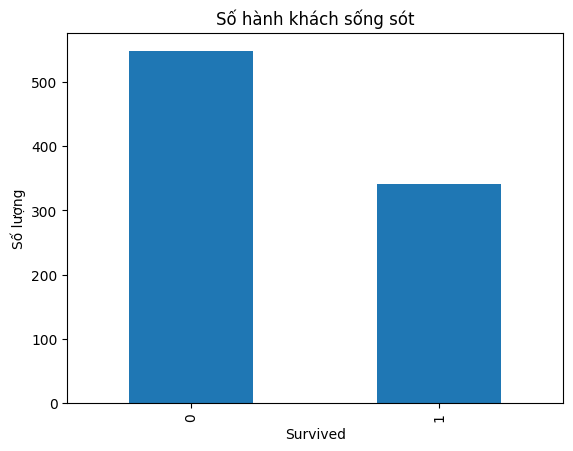

In [50]:
# Số hành khách sống sót / không sống sót
train["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Số hành khách sống sót")
plt.xlabel("Survived")
plt.ylabel("Số lượng")
plt.show()

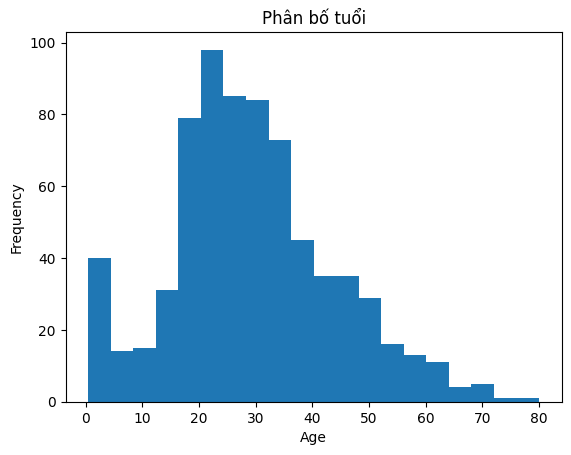

In [51]:
# Phân bố tuổi
train["Age"].plot(kind="hist", bins=20)
plt.title("Phân bố tuổi")
plt.xlabel("Age")
plt.show()

## 4. Data Preprocessing

Để giữ bài đơn giản giống tài liệu PDF, ta sử dụng các thuộc tính:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

Các bước:

- Điền tuổi thiếu bằng tuổi trung bình.
- Điền Fare thiếu bằng giá vé trung bình.
- One-hot encoding cho `Sex`, `Embarked`, `Pclass`.
- Chuẩn hóa các biến số.

In [54]:
def preprocess_titanic(df):
    data = df.copy()

    # Điền dữ liệu thiếu
    data["Age"] = data["Age"].fillna(data["Age"].mean())
    data["Fare"] = data["Fare"].fillna(data["Fare"].mean())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

    # One-hot encoding
    sex = pd.get_dummies(data["Sex"], prefix="Sex", drop_first=True)
    embark = pd.get_dummies(data["Embarked"], prefix="Embarked", drop_first=True)
    pclass = pd.get_dummies(data["Pclass"], prefix="Pclass", drop_first=True)

    data = pd.concat([data, sex, embark, pclass], axis=1)

    # Bỏ các cột không sử dụng
    data = data.drop(
        ["Pclass", "Sex", "Embarked", "Cabin", "PassengerId", "Name", "Ticket"],
        axis=1
    )

    return data


train_p = preprocess_titanic(train)
test_p = preprocess_titanic(test)

train_p.head()

,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True


### Đồng bộ cột giữa train và test

In [55]:
X = train_p.drop("Survived", axis=1)
y = train_p["Survived"]

# test không có cột Survived
X_test_kaggle = test_p.copy()

# Đảm bảo train và test có cùng cột
X, X_test_kaggle = X.align(
    X_test_kaggle,
    join="left",
    axis=1,
    fill_value=0
)

print("Các cột đầu vào:")
print(X.columns.tolist())

Các cột đầu vào:
['Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']


### Chia train / validation

In [56]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_kaggle_scaled = scaler.transform(X_test_kaggle)

print(X_train.shape, X_val.shape)

(623, 9) (268, 9)


### Chuyển sang Tensor

In [58]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_kaggle_t = torch.tensor(X_test_kaggle_scaled, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

print(X_train_t.shape, y_train_t.shape)

torch.Size([623, 9]) torch.Size([623, 1])


## 5. Define Model

Mạng MLP đơn giản:

**Input → Linear → ReLU → Linear → ReLU → Output**

In [60]:
class TitanicMLP(nn.Module):
    def __init__(self, input_size, hidden1=32, hidden2=16):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x)


model = TitanicMLP(X_train.shape[1])

print(model)

TitanicMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 6. Fit Model

Dùng:

- Loss: `BCEWithLogitsLoss`
- Optimizer: `Adam`
- Epoch: `100`

W&B chỉ được dùng để theo dõi `loss` và `accuracy` cho đơn giản.

Nếu chưa muốn kết nối W&B, đổi:

```python
WANDB_MODE = "disabled"
```

In [61]:
WANDB_MODE = "disabled"   # đổi thành "online" nếu muốn dùng W&B

run = wandb.init(
    project="titanic_pytorch_s1",
    config={
        "hidden1": 32,
        "hidden2": 16,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 100
    },
    mode=WANDB_MODE
)

In [62]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation
    model.eval()

    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits)
        val_pred = (val_probs >= 0.5).int().numpy().ravel()

    val_acc = accuracy_score(y_val, val_pred)
    avg_loss = total_loss / len(train_loader)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "val_accuracy": val_acc
    })

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} - "
            f"Loss: {avg_loss:.4f} - "
            f"Val Acc: {val_acc:.4f}"
        )

wandb.finish()

Epoch  10/100 - Loss: 0.4076 - Val Acc: 0.8097
Epoch  20/100 - Loss: 0.3730 - Val Acc: 0.7985
Epoch  30/100 - Loss: 0.3581 - Val Acc: 0.8097
Epoch  40/100 - Loss: 0.3530 - Val Acc: 0.8172
Epoch  50/100 - Loss: 0.3420 - Val Acc: 0.8134
Epoch  60/100 - Loss: 0.3358 - Val Acc: 0.8172
Epoch  70/100 - Loss: 0.3294 - Val Acc: 0.8172
Epoch  80/100 - Loss: 0.3341 - Val Acc: 0.8060
Epoch  90/100 - Loss: 0.3254 - Val Acc: 0.8097
Epoch 100/100 - Loss: 0.3170 - Val Acc: 0.8022


## 7. Model Evaluation

In [63]:
model.eval()

with torch.no_grad():
    logits = model(X_val_t)
    probs = torch.sigmoid(logits)
    predictions = (probs >= 0.5).int().numpy().ravel()

print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       165
           1       0.78      0.67      0.72       103

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.78       268
weighted avg       0.80      0.80      0.80       268



In [64]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, predictions))

print("\nAccuracy:")
print(accuracy_score(y_val, predictions))

Confusion Matrix:
[[146  19]
 [ 34  69]]

Accuracy:
0.8022388059701493


## 8. Tinh chỉnh tham số mạng đơn giản

Ta thử **3 cấu hình** khác nhau thay vì dùng Grid Search phức tạp.

Các tham số được thử:

- `hidden1`
- `hidden2`
- `learning_rate`

Mục tiêu: chọn cấu hình có Accuracy trên validation cao nhất.

In [65]:
configs = [
    {"hidden1": 16, "hidden2": 8,  "lr": 0.001},
    {"hidden1": 32, "hidden2": 16, "lr": 0.001},
    {"hidden1": 64, "hidden2": 32, "lr": 0.001}
]

results = []

for cfg in configs:

    m = TitanicMLP(
        input_size=X_train.shape[1],
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"]
    )

    optimizer = torch.optim.Adam(m.parameters(), lr=cfg["lr"])
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(50):
        m.train()

        for xb, yb in train_loader:
            optimizer.zero_grad()

            logits = m(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

    m.eval()

    with torch.no_grad():
        pred = (
            torch.sigmoid(m(X_val_t)) >= 0.5
        ).int().numpy().ravel()

    acc = accuracy_score(y_val, pred)

    results.append({
        "hidden1": cfg["hidden1"],
        "hidden2": cfg["hidden2"],
        "lr": cfg["lr"],
        "accuracy": acc,
        "model": m
    })

result_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in results
])

result_df

,hidden1,hidden2,lr,accuracy
0,16,8,0.001,0.813433
1,32,16,0.001,0.817164
2,64,32,0.001,0.824627


In [67]:
best_result = max(results, key=lambda x: x["accuracy"])

best_model = best_result["model"]

print("Cấu hình tốt nhất:")
print("hidden1 =", best_result["hidden1"])
print("hidden2 =", best_result["hidden2"])
print("lr      =", best_result["lr"])
print("accuracy=", best_result["accuracy"])

Cấu hình tốt nhất:
hidden1 = 64
hidden2 = 32
lr      = 0.001
accuracy= 0.8246268656716418


## 9. Prediction cho tập test Kaggle

Tập `test.csv` không có nhãn `Survived`.

Ta dùng `best_model` để dự đoán cho toàn bộ 418 hành khách trong tập test.

In [69]:
best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_kaggle_t)

    test_probabilities = torch.sigmoid(test_logits)

    test_predictions = (
        test_probabilities >= 0.5
    ).int().numpy().ravel()

print(test_predictions[:20])
print("Số dự đoán:", len(test_predictions))

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]
Số dự đoán: 418


## 10. Submission

File submission cần có đúng 2 cột:

- `PassengerId`
- `Survived`

Ta lấy `PassengerId` trực tiếp từ `test.csv` và dùng kết quả dự đoán của PyTorch.

In [71]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [72]:
submission.to_csv("submission_pytorch.csv", index=False)

print("Đã tạo file: submission_pytorch.csv")
print("Kích thước:", submission.shape)

Đã tạo file: submission_pytorch.csv
Kích thước: (418, 2)


### Kiểm tra file submission

In [73]:
check_submission = pd.read_csv("submission_pytorch.csv")

print(check_submission.head())
print()
print(check_submission.info())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None


## 11. Kết luận

Quy trình PyTorch trong bài:

**Load Data → Data Analysis → Data Preprocessing → Define Model → Fit Model → Model Evaluation → Tuning → Prediction → Submission**

Điểm khác so với Logistic Regression trong tài liệu mẫu là:

- Mô hình được xây dựng bằng `torch.nn.Module`.
- Huấn luyện bằng vòng lặp PyTorch.
- Dùng `BCEWithLogitsLoss`.
- Dùng `Adam`.
- Dự đoán xác suất bằng `torch.sigmoid`.
- Kết quả cuối cùng được lưu vào `submission_pytorch.csv` để nộp Kaggle.